# 04 — Auditing the Tool Before Trusting the Numbers

### Why this notebook exists

Every notebook so far has quietly leaned on one assumption: that the AI-separated
vocal and instrumental stems are *trustworthy* — that when we measure "vocal minus
instrumental" in dB, we're measuring the real vocal and the real instrumental, not
some blend of the two.

Two loose threads are waiting on that assumption:

- **Notebook 02** found Ya Dar Maya's vocal-instrumental balance swings **13.55 dB**
  across the track (vs. Elissa's tight 4.11 dB) and asked: is that a *real* mixing
  inconsistency, or is it the separation tool glitching on synthetic audio?
- **Notebook 03** found Elissa's vocal stem carries noticeably more energy in the
  250-500 Hz Low-Mid band than any Suno vocal stem, and asked: is that genuine vocal
  technique/mixing, or is something *else* leaking into that band?

Before either question can be answered, we need to check the separation tool itself.
No separation model is perfect — the real question is *how* imperfect, and whether
it's imperfect in the same way for every track. This notebook builds two label-free
audits (no ground-truth stems exist anymore to compare against directly) and finds
something nobody was looking for.

## Setup

Same core toolkit as before (`librosa`, `numpy`, `matplotlib`), plus
`librosa.feature.spectral_flatness` — a new tool we'll build intuition for in
Section B.

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

DATA_DIR = "../data"
PLOTS_DIR = "../LABS/session_2026-07-29T210000/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

SR = 22050
FRAME_SEC = 1.0

# (label, original mix, vocal stem, instrumental stem)
TRACKS = [
    ("Elissa (reference)", f"{DATA_DIR}/elisa_maktooba_leek.mp3",
     f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Vocals.mp3",
     f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Instrumental.mp3"),
    ("Ya Dar Maya (orig)", f"{DATA_DIR}/يا دار مية - 28-07-2026.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026/يا دار مية - 28-07-2026-Vocals.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026/يا دار مية - 28-07-2026-Instrumental.mp3"),
    ("SONG_A", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A/يا دار مية - 28-07-2026_SONG_A-Vocals.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A/يا دار مية - 28-07-2026_SONG_A-Instrumental.mp3"),
    ("SONG_B", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_B.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_B/يا دار مية - 28-07-2026_SONG_B-Vocals.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_B/يا دار مية - 28-07-2026_SONG_B-Instrumental.mp3"),
    ("SONG_C", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_C.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_C/يا دار مية - 28-07-2026_SONG_C-Vocals.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_C/يا دار مية - 28-07-2026_SONG_C-Instrumental.mp3"),
    ("SONG_D", f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_D.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_D/يا دار مية - 28-07-2026_SONG_D-Vocals.mp3",
     f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_D/يا دار مية - 28-07-2026_SONG_D-Instrumental.mp3"),
]

def rms_db(x, eps=1e-10):
    '''Same loudness function from Notebooks 00-03 — RMS energy converted to dB.'''
    return 20 * np.log10(np.sqrt(np.mean(x ** 2)) + eps)

def frame_signal(x, sr, frame_sec=FRAME_SEC):
    '''Chop a signal into non-overlapping 1-second frames, dropping any remainder.'''
    n = int(sr * frame_sec)
    n_frames = len(x) // n
    return x[: n_frames * n].reshape(n_frames, n)

print("Setup complete. Tracks registered:", len(TRACKS))

Setup complete. Tracks registered: 6


## A. Idea 1 — Reconstruction fidelity

The separation tool takes one mix and splits it into two stems: vocal and
instrumental. If that split is a clean, complete decomposition, a simple identity
should hold almost exactly:

$$\text{vocal} + \text{instrumental} \approx \text{original mix}$$

This doesn't require any ground truth — we already have the original mix for every
track. We just add the two stems back together and compare the sum to the original,
one second at a time, in dB. A near-zero gap means the tool accounted for (almost)
everything in the mix. A consistent negative gap means the reconstructed sum is
*quieter* than the original — some of the mix's energy didn't end up fully in either
stem.

In [2]:
def reconstruction_check(orig_path, voc_path, inst_path):
    orig, _ = librosa.load(orig_path, sr=SR, mono=True)
    voc, _ = librosa.load(voc_path, sr=SR, mono=True)
    inst, _ = librosa.load(inst_path, sr=SR, mono=True)

    n = min(len(orig), len(voc), len(inst))
    orig, voc, inst = orig[:n], voc[:n], inst[:n]
    recon = voc + inst

    orig_f, recon_f = frame_signal(orig, SR), frame_signal(recon, SR)
    err_db = np.array([rms_db(r) - rms_db(o) for o, r in zip(orig_f, recon_f)])
    corr = np.corrcoef(orig, recon)[0, 1]
    return err_db, corr

recon_results = {}
for name, orig_path, voc_path, inst_path in TRACKS:
    err_db, corr = reconstruction_check(orig_path, voc_path, inst_path)
    recon_results[name] = (err_db, corr)
    print(f"{name:22s}  median err = {np.median(err_db):+6.2f} dB   correlation = {corr:.4f}")

Elissa (reference)      median err =  -2.75 dB   correlation = 0.9993


Ya Dar Maya (orig)      median err =  -0.00 dB   correlation = 0.9999


SONG_A                  median err =  -0.00 dB   correlation = 0.9999


SONG_B                  median err =  -0.00 dB   correlation = 0.9999


SONG_C                  median err =  -0.00 dB   correlation = 1.0000


SONG_D                  median err =  -0.32 dB   correlation = 1.0000


**One track stands apart.** Elissa's reconstructed sum comes back noticeably
*quieter* than her original mix, while every Suno track reconstructs almost
perfectly (near 0 dB gap). The correlation stays extremely high for all six — the
*shape* of the reconstruction is right — but Elissa is missing real energy that
neither stem accounted for.

This makes sense once you remember what Elissa's file actually is: a real studio
recording, with room ambience, reverb tails, and mastering processing baked into the
mix. Some of that isn't cleanly "vocal" or "instrumental" — it's a shared byproduct
of both — and the separation model has to throw part of it away. Suno's audio is
synthetic and has less of that shared, hard-to-attribute material, so its split is
closer to perfectly additive.

C:\Users\DELL\AppData\Local\Temp\ipykernel_54712\3165962308.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


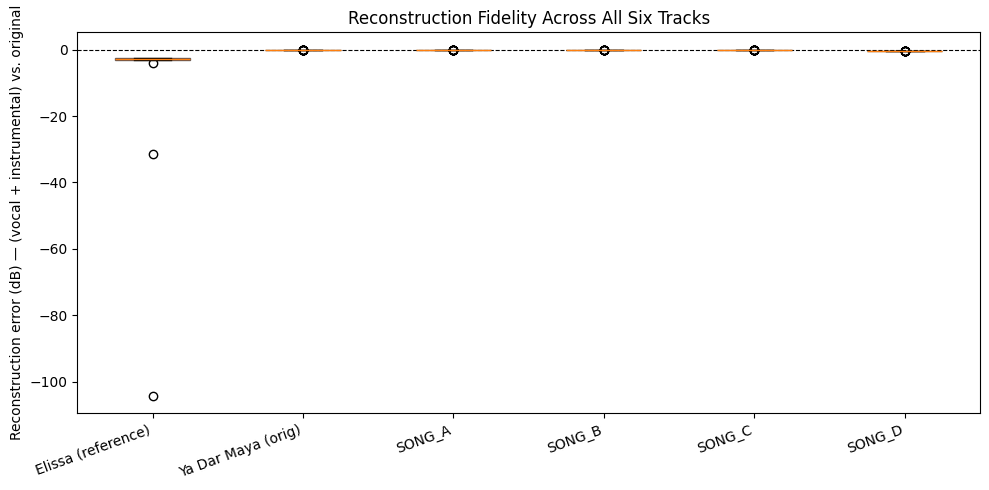

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [name for name, *_ in TRACKS]
data = [recon_results[name][0] for name in labels]
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for patch, name in zip(bp["boxes"], labels):
    patch.set_facecolor("indianred" if "Elissa" in name else "steelblue")
    patch.set_alpha(0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Reconstruction error (dB) — (vocal + instrumental) vs. original")
ax.set_title("Reconstruction Fidelity Across All Six Tracks")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/reconstruction_fidelity.png", dpi=110)
plt.show()

## B. Idea 2 — What's hiding in the "quiet" parts of the vocal stem?

Reconstruction fidelity tells us about *missing* energy. It says nothing about
*misplaced* energy — instrumental content that leaked into the vocal stem, or vice
versa. For that we need a different question: **during the parts of the song where
the vocal stem should be near-silent (nobody's singing), is it actually silent?**

If separation were perfect, those quiet stretches would just be noise floor — flat,
featureless, no musical structure. If instrumental content is bleeding through, those
same "quiet" stretches will still carry a shape: a tone, a rhythm, something
recognizably *musical* rather than random.

**Spectral flatness** is the tool for telling those two apart. It compares a
sound's *geometric* mean energy across frequencies to its *arithmetic* mean:

$$\text{flatness} = \frac{\text{geometric mean of the spectrum}}{\text{arithmetic mean of the spectrum}}$$

- White noise has energy spread evenly across every frequency → geometric mean ≈
  arithmetic mean → **flatness ≈ 1.0**.
- A tone, a chord, or a hum concentrates energy in a few frequencies → a handful of
  tall spikes drag the arithmetic mean up while the geometric mean stays low →
  **flatness close to 0**.

So: high flatness in a "quiet" vocal frame = plain noise floor (good separation).
Low flatness = something tonal is still in there (bleed).

In [4]:
# Quick calibration: flatness of pure noise vs. a pure tone, so the number means something
rng = np.random.default_rng(0)
noise = rng.normal(0, 1, SR)                                   # white noise
tone = np.sin(2 * np.pi * 220 * np.arange(SR) / SR)             # pure 220 Hz tone

noise_flat = np.mean(librosa.feature.spectral_flatness(y=noise)[0])
tone_flat = np.mean(librosa.feature.spectral_flatness(y=tone)[0])
print(f"White noise flatness: {noise_flat:.3f}  (near 1.0 = flat spectrum)")
print(f"Pure tone flatness:   {tone_flat:.3f}  (near 0.0 = spiky/tonal spectrum)")

White noise flatness: 0.562  (near 1.0 = flat spectrum)


Pure tone flatness:   0.000  (near 0.0 = spiky/tonal spectrum)


## C. Finding the quiet frames — and an unexpected discovery

The plan: for each vocal stem, chop it into 1-second frames, rank them by loudness,
and look at spectral flatness in the quietest 10%. That's where any bleed-through
should be most visible.

The first pass at this immediately surfaced something nobody was looking for.

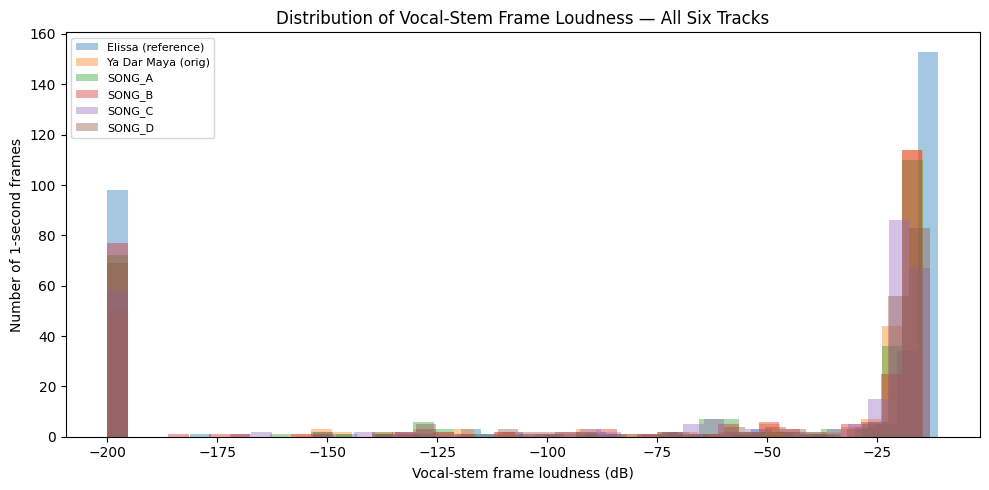

Elissa (reference)      frames at literal digital silence (<= -150 dB): 31.2%
Ya Dar Maya (orig)      frames at literal digital silence (<= -150 dB): 21.0%
SONG_A                  frames at literal digital silence (<= -150 dB): 27.9%
SONG_B                  frames at literal digital silence (<= -150 dB): 30.0%
SONG_C                  frames at literal digital silence (<= -150 dB): 22.2%
SONG_D                  frames at literal digital silence (<= -150 dB): 27.4%


In [5]:
vocal_frame_db = {}
for name, orig_path, voc_path, inst_path in TRACKS:
    voc, _ = librosa.load(voc_path, sr=SR, mono=True)
    voc_f = frame_signal(voc, SR)
    frame_db = np.array([rms_db(f) for f in voc_f])
    vocal_frame_db[name] = frame_db

fig, ax = plt.subplots(figsize=(10, 5))
for name, *_ in TRACKS:
    ax.hist(vocal_frame_db[name], bins=40, alpha=0.4, label=name)
ax.set_xlabel("Vocal-stem frame loudness (dB)")
ax.set_ylabel("Number of 1-second frames")
ax.set_title("Distribution of Vocal-Stem Frame Loudness — All Six Tracks")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/vocal_frame_loudness_histogram.png", dpi=110)
plt.show()

for name, *_ in TRACKS:
    hard_gate_frac = np.mean(vocal_frame_db[name] <= -150.0)
    print(f"{name:22s}  frames at literal digital silence (<= -150 dB): {hard_gate_frac:.1%}")

**Look at the left edge of that histogram.** A big pile of frames across every
single track sits at essentially **negative infinity dB** — not quiet, but literal
digital-zero silence (every sample is exactly 0.0). That's **21%–31% of all frames,
on all six tracks**, Elissa included.

This isn't a Suno-vs-natural difference. It looks like a **hard gate** applied
somewhere in the separation tool's pipeline (or its export step): whenever the model's
confidence that "vocal is present" drops low enough, it seems to zero the output
completely rather than leaving a faint residual. That's a property of the *tool*,
applied uniformly — useful to know, but it also means the original plan (look at the
quietest 10% of frames) needs a fix. Right now that quietest 10% would just be
measuring the gate floor, not real signal. We need to exclude the hard-gated frames
first, *then* look at what's quietest among what's left.

## D. Residual bleed in the quietest *real* frames

Re-running the quiet-frame analysis, this time excluding anything at the hard-gate
floor before ranking by loudness.

In [6]:
ZERO_GATE_DB = -150.0  # anything at/below this is the hard-gated floor, not signal

residual_results = {}
for name, orig_path, voc_path, inst_path in TRACKS:
    voc, _ = librosa.load(voc_path, sr=SR, mono=True)
    voc_f = frame_signal(voc, SR)
    frame_db = vocal_frame_db[name]

    nonzero_mask = frame_db > ZERO_GATE_DB
    nonzero_db = frame_db[nonzero_mask]
    nonzero_idx = np.where(nonzero_mask)[0]

    threshold = np.percentile(nonzero_db, 10)
    quiet_idx = nonzero_idx[frame_db[nonzero_idx] <= threshold]

    flat_vals = [np.mean(librosa.feature.spectral_flatness(y=voc_f[i])[0]) for i in quiet_idx]
    residual_results[name] = {
        "hard_silent_frac": np.mean(frame_db <= ZERO_GATE_DB),
        "quiet_rms_db": np.median(frame_db[quiet_idx]),
        "quiet_flatness": np.median(flat_vals),
    }

print(f"{'Track':22s}  {'Hard-silent %':>13s}  {'Quiet RMS (dB)':>15s}  {'Flatness':>9s}")
for name, *_ in TRACKS:
    r = residual_results[name]
    print(f"{name:22s}  {r['hard_silent_frac']:>12.1%}  {r['quiet_rms_db']:>15.1f}  {r['quiet_flatness']:>9.3f}")

Track                   Hard-silent %   Quiet RMS (dB)   Flatness
Elissa (reference)             31.2%            -88.3      0.433
Ya Dar Maya (orig)             21.0%           -120.1      0.955
SONG_A                         27.9%           -125.1      0.960
SONG_B                         30.0%           -101.5      0.667
SONG_C                         22.2%           -100.9      0.678
SONG_D                         27.4%           -110.6      0.660


**Elissa is the outlier again — in the opposite direction from what "gold
reference" might suggest.** Her quietest non-gated vocal frames sit around **−88 dB
with low flatness (≈0.4)** — a real, structured, tonal signal, not noise floor. The
Suno tracks' quietest frames sit far lower (−100 to −125 dB) with much higher
flatness (0.66–0.96) — mostly just noise, little to no tonal bleed.

Put plainly: **Elissa's "silent" gaps aren't silent.** Something tonal — almost
certainly instrumental bleed-through — is leaking into her vocal stem even when no
one is singing. Ya Dar Maya (orig) and SONG_A come out cleanest of all six; SONG_B,
C, and D sit in between.

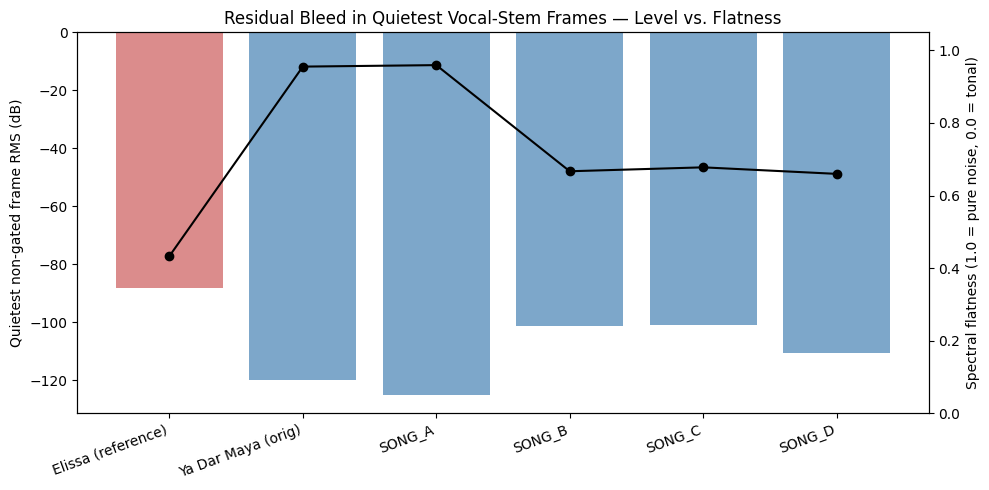

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))
names = [name for name, *_ in TRACKS]
rms_vals = [residual_results[n]["quiet_rms_db"] for n in names]
flat_vals = [residual_results[n]["quiet_flatness"] for n in names]

x = np.arange(len(names))
bars = ax1.bar(x, rms_vals, color=["indianred" if "Elissa" in n else "steelblue" for n in names], alpha=0.7)
ax1.set_ylabel("Quietest non-gated frame RMS (dB)")
ax1.set_xticks(x)
ax1.set_xticklabels(names, rotation=20, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, flat_vals, color="black", marker="o", linewidth=1.5, label="Spectral flatness")
ax2.set_ylabel("Spectral flatness (1.0 = pure noise, 0.0 = tonal)")
ax2.set_ylim(0, 1.05)

ax1.set_title("Residual Bleed in Quietest Vocal-Stem Frames — Level vs. Flatness")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/residual_bleed_level_vs_flatness.png", dpi=110)
plt.show()

## E. Closing the Notebook 02 and 03 loose threads

We now have enough to go back and answer both open questions directly.

In [8]:
print("Notebook 02's question — is Ya Dar Maya's 13.55 dB variance real or an artifact?")
r = residual_results["Ya Dar Maya (orig)"]
print(f"  Ya Dar Maya (orig) residual bleed: {r['quiet_rms_db']:.1f} dB, flatness {r['quiet_flatness']:.2f} -> among the CLEANEST separations of all six.")
print("  -> The variance measured in Notebook 02 is unlikely to be a separation artifact. It looks like a real mix property.\n")

print("Notebook 03's question — is Elissa's Low-Mid vocal energy real singing or bleed?")
r = residual_results["Elissa (reference)"]
print(f"  Elissa residual bleed: {r['quiet_rms_db']:.1f} dB, flatness {r['quiet_flatness']:.2f} -> the MOST bleed-affected separation of all six,")
print("  and the bleed is tonal/structured (low flatness), not random noise -- exactly the kind of signal that could pad out a frequency band.")
print("  -> Elissa's extra 250-500 Hz Low-Mid energy is now a suspect case, not a confirmed 'real vocal' finding.")

Notebook 02's question — is Ya Dar Maya's 13.55 dB variance real or an artifact?
  Ya Dar Maya (orig) residual bleed: -120.1 dB, flatness 0.96 -> among the CLEANEST separations of all six.
  -> The variance measured in Notebook 02 is unlikely to be a separation artifact. It looks like a real mix property.

Notebook 03's question — is Elissa's Low-Mid vocal energy real singing or bleed?
  Elissa residual bleed: -88.3 dB, flatness 0.43 -> the MOST bleed-affected separation of all six,
  and the bleed is tonal/structured (low flatness), not random noise -- exactly the kind of signal that could pad out a frequency band.
  -> Elissa's extra 250-500 Hz Low-Mid energy is now a suspect case, not a confirmed 'real vocal' finding.


Neither thread is *fully* closed — this audit uses proxies, not ground-truth
stems, because no official stems survive for comparison (see `context.md` §1). But
the direction of evidence is now much clearer than it was:

- **Ya Dar Maya's high variance (Notebook 02): stays trustworthy.** Clean
  separation + big swings = a real mixing inconsistency, not measurement noise.
- **Elissa's Low-Mid energy concentration (Notebook 03): now flagged, not
  confirmed.** The same track carries the most tonal bleed of all six — some
  fraction of that "vocal" energy in 250-500 Hz could be leaking instrumental
  content, not the singer's voice.
- **A new caution flag for SONG_B and SONG_C**, whose moderate bleed (flatness
  0.66-0.68) means their Notebook 02 variance numbers should be trusted a little
  less than Ya Dar Maya's or SONG_A's.
- **Elissa's own baseline numbers throughout this project (+3.33 dB median
  prominence, 4.11 dB std) now carry a caution flag too.** The "gold reference"
  track turns out to have the noisiest separation of the six, not the cleanest.

## Self-Check

Try to answer each question yourself before expanding the answer.

<details>
<summary><b>Q1.</b> In your own words, what does it mean for <code>vocal + instrumental</code> to reconstruct the original mix with high correlation but a negative dB gap, the way Elissa's does?</summary>

High correlation means the reconstructed sum has the right *shape* over time — it
rises and falls in the same places as the original. A negative dB gap means it's
consistently *quieter* — some real energy from the original mix isn't showing up in
either stem's sum. The shape survives; the level doesn't fully add up.
</details>

<details>
<summary><b>Q2.</b> Why does high spectral flatness indicate good separation in a "quiet" vocal-stem frame, while low flatness indicates a problem?</summary>

A frame where nobody is singing should, if separation is clean, contain nothing but
noise floor — energy spread evenly across all frequencies, which is what "flatness
close to 1.0" measures. If instead the frame has a handful of dominant frequencies
(low flatness), that's a tonal, structured signal — almost certainly a piece of the
instrumental bed that leaked in rather than genuine background noise.
</details>

<details>
<summary><b>Q3.</b> The hard-gate discovery (21-31% of frames at literal digital silence) was found on every single track, Elissa included. Why does that make it a tool artifact rather than a real finding about any one track's mix?</summary>

If the pattern only showed up on, say, the Suno tracks, it could be a genuine
difference in how those tracks were mixed or how "quiet the singer actually gets."
But because the *same* proportion range appears uniformly across a real studio
recording (Elissa) and four different AI-generated covers, the common factor has to
be the one thing they all share: the separation/export pipeline itself, not the
music.
</details>

<details>
<summary><b>Q4.</b> Elissa is the project's "gold reference" track, yet this notebook found she has the most residual bleed of all six. Why doesn't that automatically mean her earlier numbers (Notebook 02's +3.33 dB, 4.11 dB std) are wrong?</summary>

"Gold reference" describes her *musical/production* role in the project (the
professionally mixed benchmark we compare Suno tracks against) — it says nothing
about how cleanly the separation *tool* happens to split her particular audio.
Reconstruction fidelity and residual bleed are two separate axes: a track can be an
excellent reference for what a well-produced vocal balance sounds like, while still
being a harder case for this specific AI separation model to isolate cleanly. The
numbers aren't proven wrong here — they're flagged as needing more caution than the
Suno tracks' numbers, because more of the signal feeding into them is technically bleed.
</details>

## Summary — what you now have

- **Reconstruction fidelity**: `vocal + instrumental` should sum back to the
  original mix if separation is clean. All six tracks reconstruct with very high
  correlation, but Elissa's sum is measurably quieter than her original — real
  studio ambience/mastering that the separation model can't cleanly assign to
  either stem. The Suno tracks, being synthetic, reconstruct almost perfectly.
- **Spectral flatness**: a way to tell noise (flatness ≈ 1.0) apart from tonal
  content (flatness ≈ 0), calibrated here on pure noise vs. a pure tone before
  using it on real audio.
- **The hard-gate discovery**: 21%-31% of every vocal stem's frames, on all six
  tracks, are literal digital-zero silence — a uniform artifact of the separation
  pipeline, not a musical difference between tracks.
- **Residual bleed, measured correctly** (excluding the hard-gated frames):
  Elissa's quiet vocal-stem frames carry real, tonal bleed (−88 dB, flatness 0.43)
  — the most of any of the six tracks. Ya Dar Maya (orig) and SONG_A are the
  cleanest; SONG_B/C/D sit in between.
- **Two loose threads addressed**: Ya Dar Maya's high consistency variance
  (Notebook 02) looks real, not a separation artifact. Elissa's Low-Mid vocal
  energy concentration (Notebook 03) is now a suspect case rather than a confirmed
  finding, given how much bleed her stems carry.
- **Next up (Notebook 05)**: the project owner reported hearing an obvious,
  consistent reverb tail on Elissa's isolated vocal that Suno vocals don't share —
  and this notebook's flatness finding (Elissa's residual being the most tonal/
  structured of all six) lines up with that description. Notebook 05 tries to
  *measure* that reverb-tail difference automatically, and documents why that
  automated attempt didn't hold up.